# 🚲 HLBT Baku - Bike: Velosiped İcarəsi Proqnozu

**Məqsəd:** Hava şəraiti, vaxt və digər faktorlara əsasən saatlıq velosiped icarəsini proqnozlaşdırmaq.

**Metrika:** MAE (Mean Absolute Error) — nə qədər aşağı olsa, bir o qədər yaxşıdır.

**Pipeline:**
1. Kitabxanaları yüklə
2. Datanı oxu
3. EDA (Exploratory Data Analysis)
4. Data təmizliyi
5. Feature Engineering
6. Model qur
7. Submission faylı hazırla

## 📦 1. Kitabxanaları yüklə

In [ ]:


import pandas as pd          # Cədvəl (DataFrame) işləmək üçün
import numpy as np           # Riyazi əməliyyatlar üçün

# Vizualizasiya kitabxanaları
import matplotlib.pyplot as plt   # Qrafik çəkmək üçün
import seaborn as sns             # Daha gözəl qrafiklər üçün

# Maşın öyrənməsi kitabxanaları
from sklearn.ensemble import RandomForestRegressor   # Random Forest modeli
from sklearn.model_selection import cross_val_score  # Cross-validation
from sklearn.metrics import mean_absolute_error      # MAE hesablamaq üçün

# Xəbərdarlıqları gizlət (kod daha səliqəli görünsün)
import warnings
warnings.filterwarnings('ignore')

# Qrafik ölçüsünü ayarla
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

print('✅ Bütün kitabxanalar uğurla yükləndi!')

✅ Bütün kitabxanalar uğurla yükləndi!


## 📂 2. Datanı oxu

In [7]:
# CSV fayllarını pandas DataFrame-ə oxu
# Fayllar bu notebook ilə eyni qovluqda olmalıdır
train = pd.read_csv('train.csv')            # Öyrətmə datası
test  = pd.read_csv('test.csv')             # Test datası (count yoxdur)
sub   = pd.read_csv('sample_submission.csv') # Göndərmə nümunəsi

print(f'Train ölçüsü : {train.shape}')   # (sətir sayı, sütun sayı)
print(f'Test ölçüsü  : {test.shape}')
print(f'Submission   : {sub.shape}')

Train ölçüsü : (8943, 12)
Test ölçüsü  : (1943, 9)
Submission   : (1943, 2)


In [8]:
# İlk 5 sətirə bax — datanın necə göründüyünü anla
train.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,18,21
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,24,32
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,4,29,33
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,1,13,14
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,0,0


In [9]:
# Hər sütunun tipi və boş dəyər sayı
# object = mətn, int64 = tam ədəd, float64 = onluq ədəd
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 8943 entries, 0 to 8942
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    8943 non-null   str    
 1   season      8943 non-null   int64  
 2   holiday     8943 non-null   int64  
 3   workingday  8943 non-null   int64  
 4   weather     8943 non-null   int64  
 5   temp        8943 non-null   float64
 6   atemp       8943 non-null   float64
 7   humidity    8943 non-null   int64  
 8   windspeed   8943 non-null   float64
 9   casual      8943 non-null   int64  
 10  registered  8943 non-null   int64  
 11  count       8943 non-null   int64  
dtypes: float64(3), int64(8), str(1)
memory usage: 838.5 KB


In [10]:
# Statistik icmal: min, max, ortalama, standart kənara çıxma
train.describe().round(2)

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,8943.00,8943.00,8943.00,8943.00,8943.00,8943.00,8943.00,8943.00,8943.00,8943.00,8943.00
mean,2.25,0.03,0.68,1.41,20.35,23.80,61.11,13.00,34.32,142.02,176.33
std,1.05,0.16,0.46,0.64,8.07,8.79,19.60,8.28,48.45,139.10,169.19
min,1.00,0.00,0.00,1.00,0.82,0.76,0.00,0.00,-3.00,-6.00,-7.00
25%,1.00,0.00,0.00,1.00,13.94,16.66,46.00,7.00,3.00,32.00,38.00
50%,2.00,0.00,1.00,1.00,20.50,24.24,61.00,13.00,15.00,108.00,131.00
75%,3.00,0.00,1.00,2.00,27.06,31.06,77.00,19.00,47.00,204.00,263.00
max,4.00,1.00,1.00,4.00,41.00,45.46,100.00,57.00,366.00,792.00,891.00


## 🔍 3. EDA — Datanı kəşf et

In [11]:
# Boş dəyər yoxlaması
# isnull() — hər hücrə boşdurmu? True/False qaytarır
# sum() — True-ları say
print('Boş dəyərlər:')
print(train.isnull().sum())

Boş dəyərlər:
datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
dtype: int64


In [12]:
# Mənfi count dəyərləri — bunlar data xətasıdır
neg_mask = train['count'] < 0
print(f'Mənfi count sayı: {neg_mask.sum()}')
print(f'Ən kiçik dəyər : {train["count"].min()}')

# Mənfi olan sətirləri göstər
train[neg_mask].head()

Mənfi count sayı: 87
Ən kiçik dəyər : -7


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
7,2011-01-01 07:00:00,1,0,0,1,8.20,12.880,86,0.0000,2,-3,-1
30,2011-01-02 07:00:00,1,0,0,2,16.40,20.455,76,12.9980,-2,0,-2
49,2011-01-03 04:00:00,1,0,1,1,6.56,6.820,47,26.0027,0,-1,-1
93,2011-01-05 01:00:00,1,0,1,1,6.56,9.850,74,6.0032,0,-1,-1
119,2011-01-06 05:00:00,1,0,1,2,5.74,9.090,69,6.0032,-1,0,-1


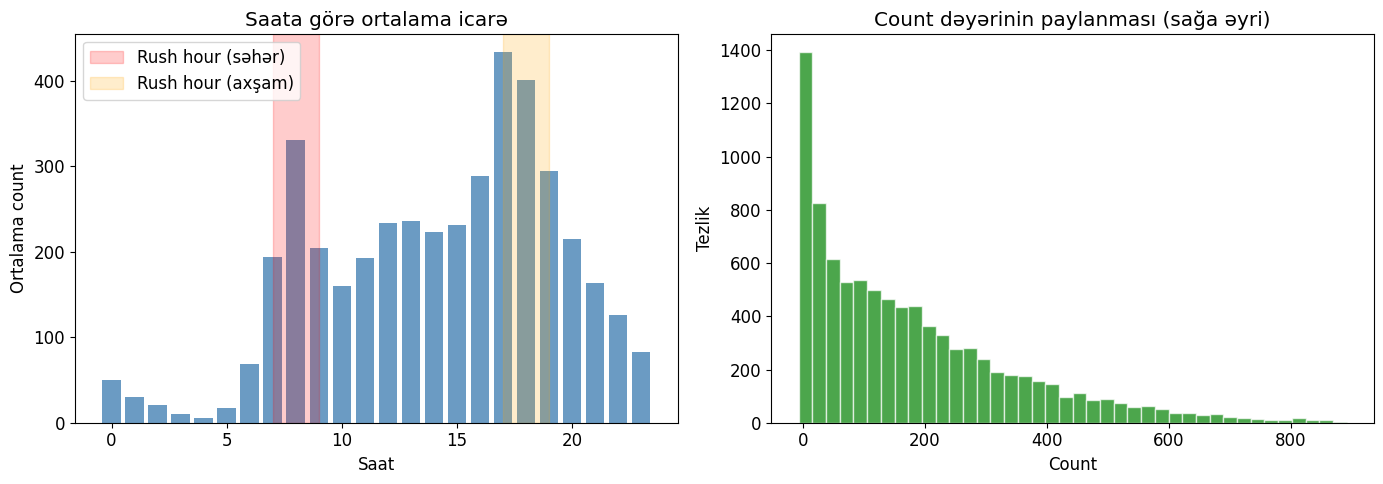

In [13]:
# datetime sütununu tarix formatına çevir (hələlik EDA üçün)
train['datetime'] = pd.to_datetime(train['datetime'])

# Saatlıq ortalama icarə
by_hour = train.groupby(train['datetime'].dt.hour)['count'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sol: Saata görə icarə
axes[0].bar(by_hour.index, by_hour.values, color='steelblue', alpha=0.8)
axes[0].set_title('Saata görə ortalama icarə')
axes[0].set_xlabel('Saat')
axes[0].set_ylabel('Ortalama count')
axes[0].axvspan(7, 9, alpha=0.2, color='red', label='Rush hour (səhər)')
axes[0].axvspan(17, 19, alpha=0.2, color='orange', label='Rush hour (axşam)')
axes[0].legend()

# Sağ: Count paylanması
axes[1].hist(train['count'], bins=40, color='green', alpha=0.7, edgecolor='white')
axes[1].set_title('Count dəyərinin paylanması (sağa əyri)')
axes[1].set_xlabel('Count')
axes[1].set_ylabel('Tezlik')

plt.tight_layout()
plt.show()

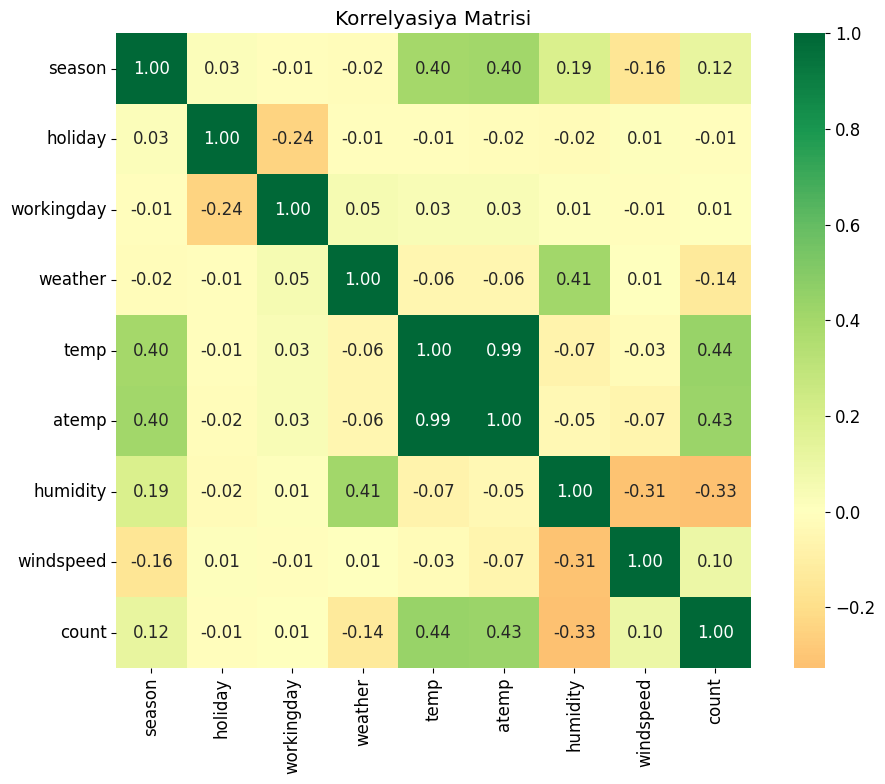

Count ilə korrelyasiya (güclüdən zəifə):
temp          0.436232
atemp         0.432546
season        0.121471
windspeed     0.100845
workingday    0.007313
holiday      -0.009842
weather      -0.137454
humidity     -0.326328
Name: count, dtype: float64


In [14]:
# Korrelyasiya matrisi — hansı feature count ilə ən çox bağlıdır?
# Korrelyasiya: +1 = mükəmməl müsbət, -1 = mükəmməl mənfi, 0 = əlaqə yoxdur

num_cols = ['season','holiday','workingday','weather','temp',
            'atemp','humidity','windspeed','count']

corr = train[num_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,      # Dəyərləri göstər
    fmt='.2f',       # 2 onluq rəqəm
    cmap='RdYlGn',   # Qırmızı (mənfi) → Yaşıl (müsbət)
    center=0,        # 0 mərkəzdə
    square=True
)
plt.title('Korrelyasiya Matrisi')
plt.tight_layout()
plt.show()

print('Count ilə korrelyasiya (güclüdən zəifə):')
print(corr['count'].drop('count').sort_values(ascending=False))

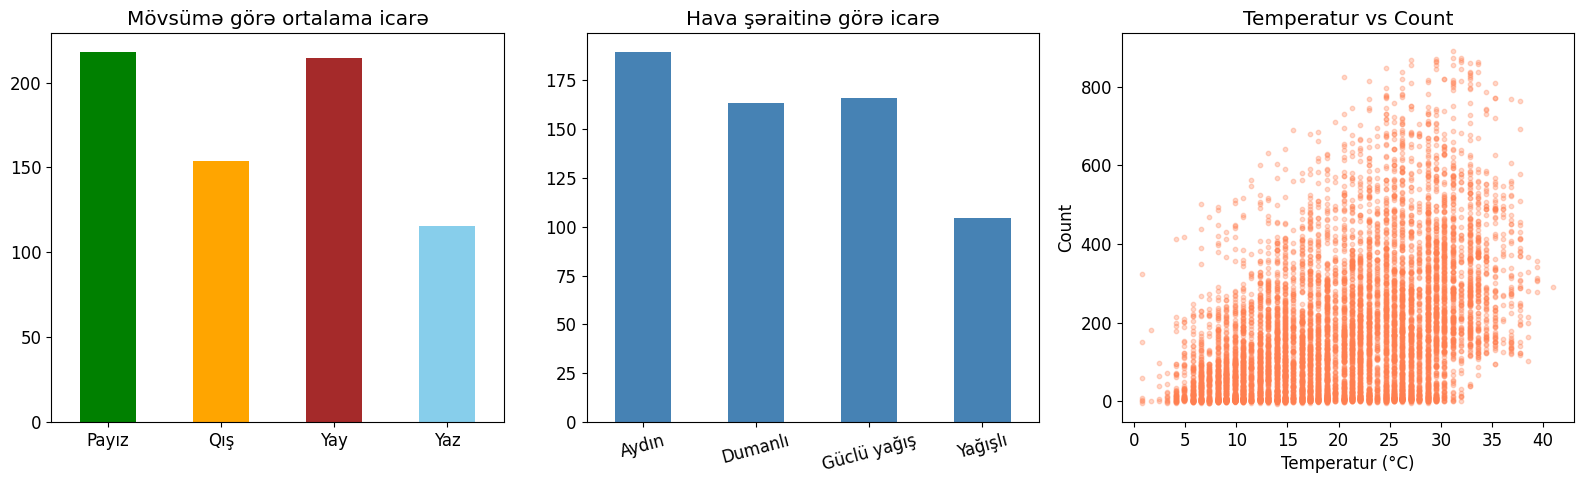

In [15]:
# Mövsüm, hava, həftə günü üzrə vizual analiz
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Mövsüm
season_map = {1: 'Yaz', 2: 'Yay', 3: 'Payız', 4: 'Qış'}
train['season_name'] = train['season'].map(season_map)
train.groupby('season_name')['count'].mean().plot(kind='bar', ax=axes[0],
    color=['green','orange','brown','skyblue'], rot=0)
axes[0].set_title('Mövsümə görə ortalama icarə')
axes[0].set_xlabel('')

# Hava
weather_map = {1: 'Aydın', 2: 'Dumanlı', 3: 'Yağışlı', 4: 'Güclü yağış'}
train['weather_name'] = train['weather'].map(weather_map)
train.groupby('weather_name')['count'].mean().plot(kind='bar', ax=axes[1],
    color='steelblue', rot=15)
axes[1].set_title('Hava şəraitinə görə icarə')
axes[1].set_xlabel('')

# Temp vs Count scatter
axes[2].scatter(train['temp'], train['count'], alpha=0.3, s=10, color='coral')
axes[2].set_title('Temperatur vs Count')
axes[2].set_xlabel('Temperatur (°C)')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

## 🧹 4. Data Təmizliyi

In [16]:
# Mənfi count dəyərlərini sil — bunlar data xətasıdır
before = len(train)

train = train[train['count'] >= 0].copy()
# .copy() — orijinal datanı dəyişdirməmək üçün yeni kopya yaradır

after = len(train)
print(f'Silindən əvvəl: {before} sətir')
print(f'Silindikdən sonra: {after} sətir')
print(f'Silindi: {before - after} sətir')

Silindən əvvəl: 8943 sətir
Silindikdən sonra: 8856 sətir
Silindi: 87 sətir


## ⚙️ 5. Feature Engineering — Yeni sütunlar yarat

**Feature Engineering** — mövcud məlumatdan yeni, daha faydalı sütunlar yaratmaq deməkdir.
Məsələn, `datetime`-dən `hour` çıxarmaq modelin vaxt nümunəsini öyrənməsinə kömək edir.

In [17]:
def add_features(df):
    """
    Hər iki dataset üçün (train və test) eyni feature-ləri əlavə edir.
    Funksiya yazmağın üstünlüyü: kodu iki dəfə yazmırıq, səhv riski azalır.
    """
    df = df.copy()  # Orijinalı qorumaq üçün

    # datetime sütununu pandas tarix formatına çevir
    df['datetime'] = pd.to_datetime(df['datetime'])

    # Tarixdən yeni sütunlar çıxar
    df['hour']    = df['datetime'].dt.hour       # 0-23: günün saatı
    df['month']   = df['datetime'].dt.month      # 1-12: il ayı
    df['weekday'] = df['datetime'].dt.dayofweek  # 0=Bazar ertəsi, 6=Bazar
    df['year']    = df['datetime'].dt.year       # 2011 və ya 2012

    # Rush hour: səhər (7-9) və axşam (17-19) pik saatları
    # .isin() — dəyər həmin siyahıdadırmı? True/False qaytarır
    # .astype(int) — True→1, False→0 çevirir
    df['rush_hour'] = df['hour'].isin([7, 8, 9, 17, 18, 19]).astype(int)

    # Gecə saatları: adətən çox az icarə var
    df['night'] = df['hour'].isin([0, 1, 2, 3, 4, 5]).astype(int)

    # İş günü + Rush hour birləşməsi
    # İş günündə rush hour → çox icarə
    # Həftə sonunda həmin saatlar → az icarə
    df['workingday_rush'] = df['workingday'] * df['rush_hour']

    return df


# Hər iki dataset-ə tətbiq et
train = add_features(train)
test  = add_features(test)

print('Yeni sütunlar əlavə edildi!')
print('Train sütunları:', list(train.columns))

Yeni sütunlar əlavə edildi!
Train sütunları: ['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count', 'season_name', 'weather_name', 'hour', 'month', 'weekday', 'year', 'rush_hour', 'night', 'workingday_rush']


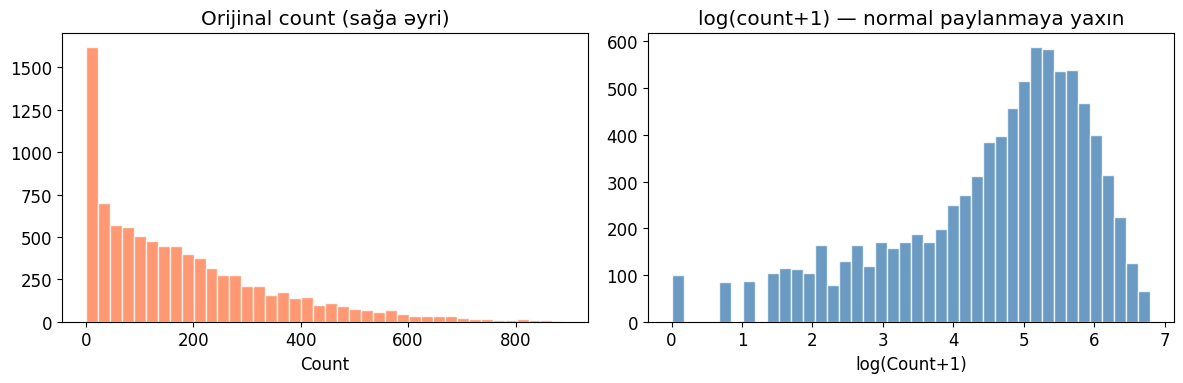

In [18]:
# Log Transform — count-u logaritmik skala ilə çevir
#
# Niyə lazımdır?
# - count sağa əyridir (çox kiçik, az böyük dəyər var)
# - Log transform bu əyriliyi düzəldir
# - MAE metrikası log scaleda daha yaxşı işləyir
#
# np.log1p(x) = log(x+1)  →  0 dəyərini qorumaq üçün +1 əlavə edirik
# (log(0) = -sonsuz olduğundan xəta verər)

train['log_count'] = np.log1p(train['count'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(train['count'], bins=40, color='coral', alpha=0.8, edgecolor='white')
axes[0].set_title('Orijinal count (sağa əyri)')
axes[0].set_xlabel('Count')

axes[1].hist(train['log_count'], bins=40, color='steelblue', alpha=0.8, edgecolor='white')
axes[1].set_title('log(count+1) — normal paylanmaya yaxın')
axes[1].set_xlabel('log(Count+1)')

plt.tight_layout()
plt.show()

## 🤖 6. Model Qur

In [19]:
# Modelin istifadə edəcəyi sütunları seç
# 'casual', 'registered', 'count', 'log_count' — bunlar TARGET-dır, feature deyil!
# 'datetime', 'season_name', 'weather_name' — model üçün lazımsız

features = [
    'season', 'holiday', 'workingday', 'weather',  # Kateqoriyalı
    'temp', 'atemp', 'humidity', 'windspeed',       # Ədədi
    'hour', 'month', 'weekday', 'year',             # Zamanla bağlı (yeni)
    'rush_hour', 'night', 'workingday_rush'         # Düzəldilmiş (yeni)
]

# X = featurelər (giriş), y = target (çıxış)
X      = train[features]
y      = train['log_count']   # Log-u öyrənir, sonra geri çeviririk
X_test = test[features]

print(f'X ölçüsü    : {X.shape}')
print(f'y ölçüsü    : {y.shape}')
print(f'X_test ölçüsü: {X_test.shape}')

X ölçüsü    : (8856, 15)
y ölçüsü    : (8856,)
X_test ölçüsü: (1943, 15)


In [20]:
# Cross-Validation (Çarpaz Doğrulama)
#
# Niyə lazımdır?
# - Modeli bütün data ilə öyrətsən, skoru necə yoxlayacaqsan?
# - CV datanı 5 hissəyə bölür, növbə ilə 1-ini test kimi istifadə edir
# - 5 fərqli skor alırsan → ortalamaları götür = etibarlı qiymət
#
# cv=5 → 5-fold cross validation
# n_jobs=-1 → bütün CPU nüvələrini işlət (sürətli)

rf = RandomForestRegressor(
    n_estimators=200,   # 200 qərar ağacı
    random_state=42,    # Nəticə hər dəfə eyni olsun
    n_jobs=-1           # Paralel işlə
)

print('Cross-validation başlayır... (1-2 dəqiqə çəkə bilər)')

# scoring='neg_mean_absolute_error' — sklearn mənfi dəyər qaytarır
# Biz -1 ilə vururuq ki, müsbət olsun
cv_scores = cross_val_score(rf, X, y, cv=5, scoring='neg_mean_absolute_error')
cv_mae = -cv_scores.mean()

print(f'\n5 CV skoru   : {(-cv_scores).round(4)}')
print(f'Ortalama MAE : {cv_mae:.4f} (log scale)')
print(f'\nBu o deməkdir ki, model ortalama ~{np.expm1(cv_mae):.1f} vahid yanılır')

Cross-validation başlayır... (1-2 dəqiqə çəkə bilər)

5 CV skoru   : [0.6645 0.2792 0.3124 0.5403 0.2861]
Ortalama MAE : 0.4165 (log scale)

Bu o deməkdir ki, model ortalama ~0.5 vahid yanılır


In [21]:
# Tam datanı istifadə edərək final modeli öyrət
# CV yalnız skor qiymətləndirmək üçün idi
# İndi bütün train datası ilə öyrədirik ki, daha güclü olsun

print('Final model öyrədilir...')
rf.fit(X, y)
print('✅ Model hazırdır!')

Final model öyrədilir...
✅ Model hazırdır!


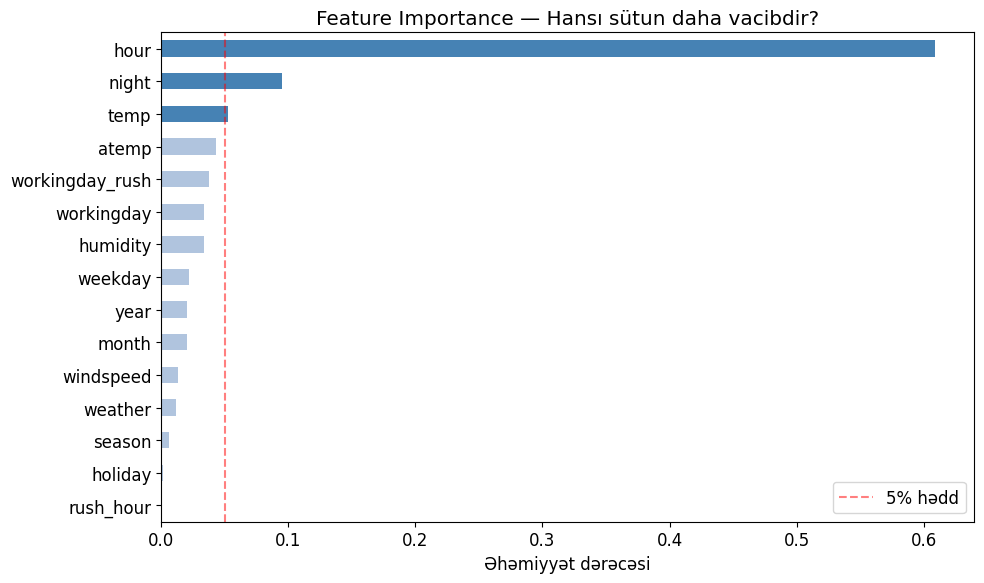


Ən vacib 5 feature:
hour               0.6091
night              0.0951
temp               0.0524
atemp              0.0433
workingday_rush    0.0374
dtype: float64


In [22]:
# Feature Importance — hansı sütun modeli daha çox istiqamətləndirir?
importances = pd.Series(rf.feature_importances_, index=features)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
colors = ['steelblue' if v > 0.05 else 'lightsteelblue' for v in importances.values]
importances.plot(kind='barh', color=colors)
plt.title('Feature Importance — Hansı sütun daha vacibdir?')
plt.xlabel('Əhəmiyyət dərəcəsi')
plt.axvline(x=0.05, color='red', linestyle='--', alpha=0.5, label='5% hədd')
plt.legend()
plt.tight_layout()
plt.show()

print('\nƏn vacib 5 feature:')
print(importances.sort_values(ascending=False).head().round(4))

## 📤 7. Proqnoz et və Submission faylı hazırla

In [23]:
# Test datası üçün proqnoz
preds_log = rf.predict(X_test)

# Log scaleni geri çevir: expm1(x) = e^x - 1
# Bu log1p()-in tam əksidir
preds = np.expm1(preds_log)

# Tam ədədə çevir (icarə sayı kəsr ola bilməz)
preds = preds.round().astype(int)

# Mənfi proqnozları 0-a çevir (məntiqsiz dəyərləri düzəlt)
preds = np.maximum(preds, 0)

print(f'Proqnoz statistikası:')
print(f'  Minimum : {preds.min()}')
print(f'  Maksimum: {preds.max()}')
print(f'  Ortalama: {preds.mean():.1f}')
print(f'  Sətir sayı: {len(preds)}')

Proqnoz statistikası:
  Minimum : 1
  Maksimum: 832
  Ortalama: 212.4
  Sətir sayı: 1943


In [24]:
# Submission faylını yarat
# Kaggle formatı: datetime_id, count
sub['count'] = preds

# Faylı yadda saxla
sub.to_csv('submission.csv', index=False)
# index=False → sıra nömrəsini (0,1,2...) fayla yazma

print('✅ submission.csv hazırdır!')
print(f'Kaggle-a yükləmək üçün bu faylı istifadə et.')
print()
print('İlk 5 sətir:')
sub.head()

✅ submission.csv hazırdır!
Kaggle-a yükləmək üçün bu faylı istifadə et.

İlk 5 sətir:


,datetime_id,count
0,1344988800,49
1,1344992400,20
2,1344996000,6
3,1344999600,5
4,1345003200,8


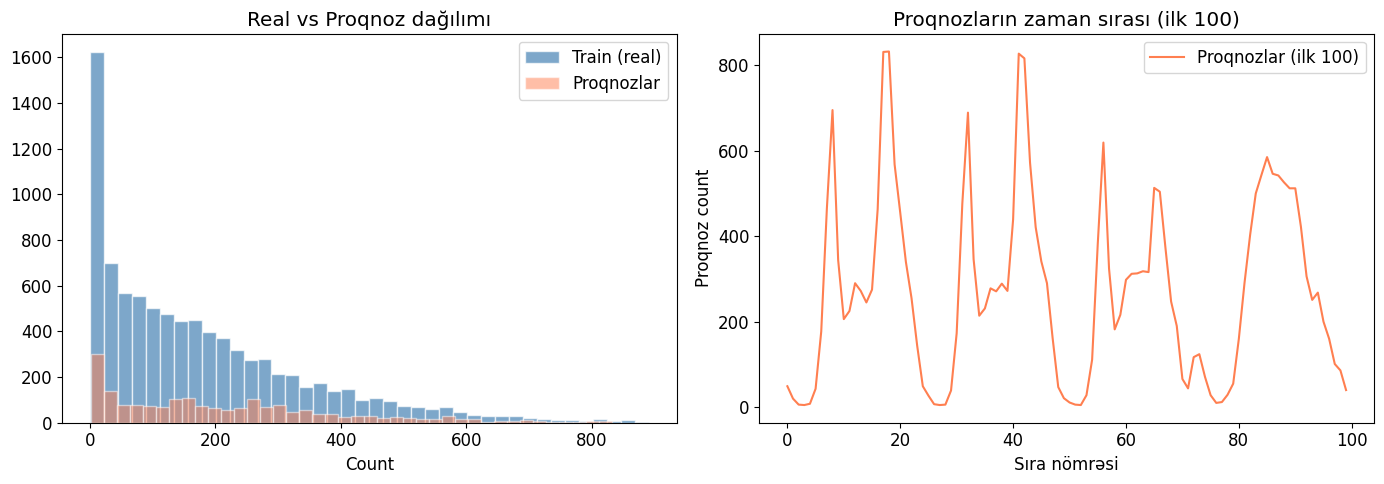

Əgər iki histoqram oxşar formadadırsa — model yaxşı işləyir!


In [25]:
# Proqnozların vizual yoxlaması
# Real train dağılımı ilə proqnoz dağılımını müqayisə et
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(train['count'], bins=40, color='steelblue', alpha=0.7,
             edgecolor='white', label='Train (real)')
axes[0].hist(preds, bins=40, color='coral', alpha=0.5,
             edgecolor='white', label='Proqnozlar')
axes[0].set_title('Real vs Proqnoz dağılımı')
axes[0].set_xlabel('Count')
axes[0].legend()

axes[1].plot(preds[:100], color='coral', linewidth=1.5, label='Proqnozlar (ilk 100)')
axes[1].set_title('Proqnozların zaman sırası (ilk 100)')
axes[1].set_xlabel('Sıra nömrəsi')
axes[1].set_ylabel('Proqnoz count')
axes[1].legend()

plt.tight_layout()
plt.show()

print('Əgər iki histoqram oxşar formadadırsa — model yaxşı işləyir!')

## 🏁 Xülasə

| Addım | Nə etdik |
|---|---|
| 1 | Kitabxanaları yüklədik |
| 2 | train.csv, test.csv oxuduq |
| 3 | EDA: saatlar, mövsüm, korrelyasiya |
| 4 | 87 mənfi count-u sildik |
| 5 | hour, month, weekday, rush_hour, night əlavə etdik |
| 6 | log1p(count) ilə öyrətdik, Random Forest (200 ağac, CV=5) |
| 7 | submission.csv hazırladıq |

**Skoru yaxşılaşdırmaq üçün növbəti addımlar:**
- LightGBM modeli ilə dəyiş
- Optuna ilə hyperparameter tuning
- `casual` və `registered` ayrı-ayrı proqnozlaşdır